In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.losses import CategoricalCrossentropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train = r'data\train'

# Image data loading
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=24,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=True,
    crop_to_aspect_ratio=False,
)

Found 19992 files belonging to 7 classes.


In [3]:
test=r'data\test'

In [4]:
# Use the Image Data Generator to import the images from the dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255,
                                  shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)


In [5]:
# Make sure you provide the same target size as initialied for the image size
train_set = train_datagen.flow_from_directory(train,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 19992 images belonging to 7 classes.


In [6]:
val_set = test_datagen.flow_from_directory(test,
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 7173 images belonging to 7 classes.


In [7]:
train_set.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

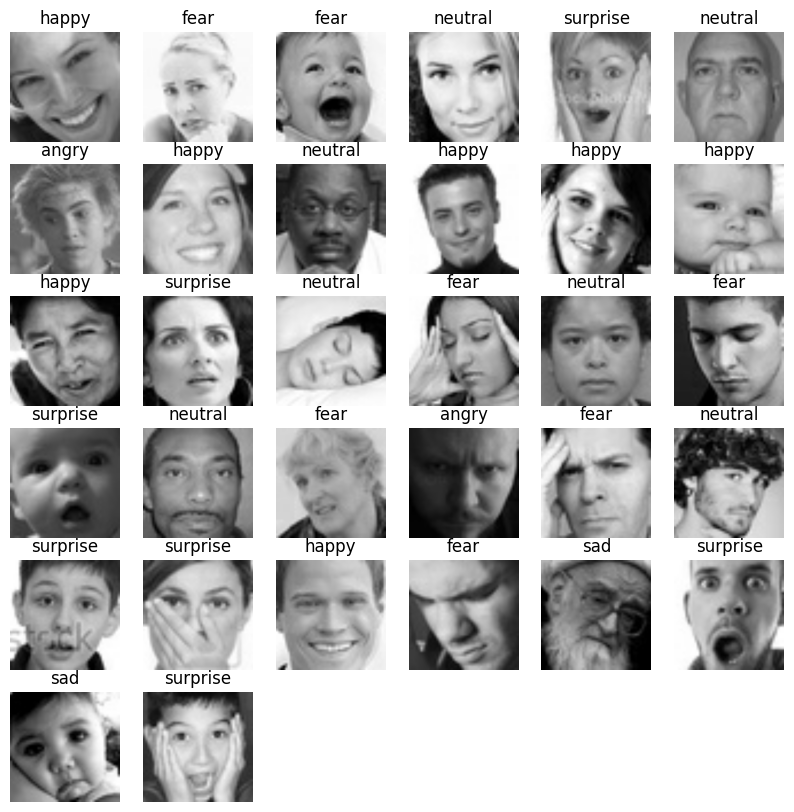

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
class_names = train_ds.class_names

for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        # Extract the class label from the one-hot encoded array
        class_label_index = int(np.argmax(labels[i]))
        plt.title(class_names[class_label_index])
        
        plt.axis("off")

plt.show()

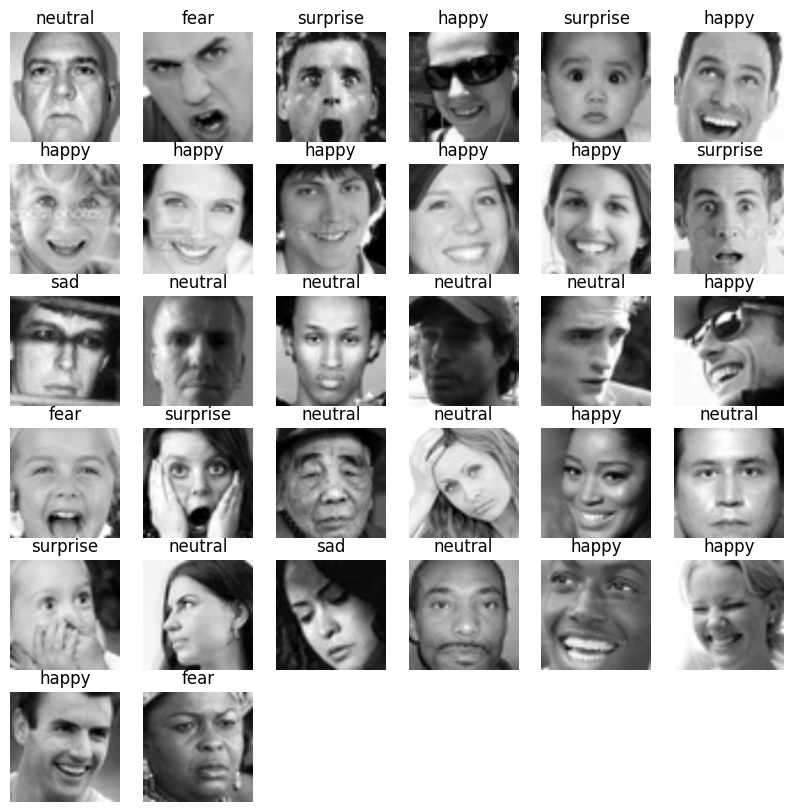

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
class_names = train_ds.class_names

for images, labels in train_ds.take(2):
    for i in range(32):
        ax = plt.subplot(6, 6, i + 1)
        
        # Convert RGB image to grayscale
        grayscale_image = np.dot(images[i].numpy(), [0.2989, 0.5870, 0.1140])
        plt.imshow(grayscale_image, cmap='gray')
        
        # Extract the class label from the one-hot encoded array
        class_label_index = int(np.argmax(labels[i]))
        plt.title(class_names[class_label_index])
        
        plt.axis("off")

plt.show()

In [10]:
# Load pre-trained Mobilnetnet model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional layers
for layer in base_model.layers:
    layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(7, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │       439,047 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,697,031 (10.29 MB)

 Trainable params: 439,047 (1.67 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Train the model
history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=35
)

Epoch 1/35


e:\emotion\env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 499s 789ms/step - accuracy: 0.3765 - loss: 7.8749 - val_accuracy: 0.4146 - val_loss: 7.1802
Epoch 2/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 509s 812ms/step - accuracy: 0.4847 - loss: 5.9303 - val_accuracy: 0.4270 - val_loss: 7.4427
Epoch 3/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 476s 759ms/step - accuracy: 0.5136 - loss: 6.2716 - val_accuracy: 0.4562 - val_loss: 7.4324
Epoch 4/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 470s 750ms/step - accuracy: 0.5382 - loss: 6.2810 - val_accuracy: 0.4454 - val_loss: 8.1204
Epoch 5/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 476s 760ms/step - accuracy: 0.5489 - loss: 6.0988 - val_accuracy: 0.4269 - val_loss: 13.3139
Epoch 6/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 482s 769ms/step - accuracy: 0.5738 - loss: 5.9899 - val_accuracy: 0.4168 - val_loss: 10.9049
Epoch 7/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 470s 749ms/step - accuracy: 0.5759 - loss: 5.7756 - val_accuracy: 0.4411 - val_loss: 11.0207
Epoch 8/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 474s 757ms/step - accuracy: 0.5834 - loss: 5

In [12]:
model.evaluate(val_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 129s 573ms/step - accuracy: 0.4907 - loss: 13.7330


[13.811755180358887, 0.48835912346839905]

C:\Users\DASSEMMANUEL\AppData\Local\Temp\ipykernel_18688\1006133107.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


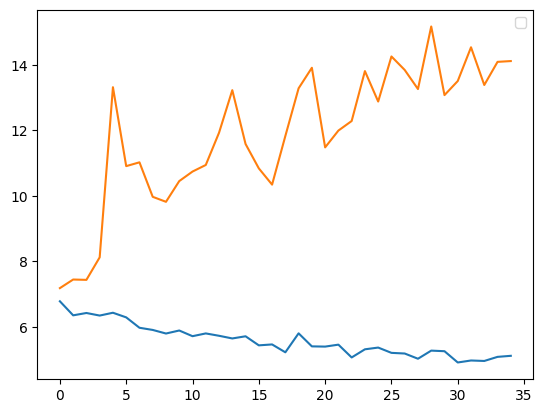

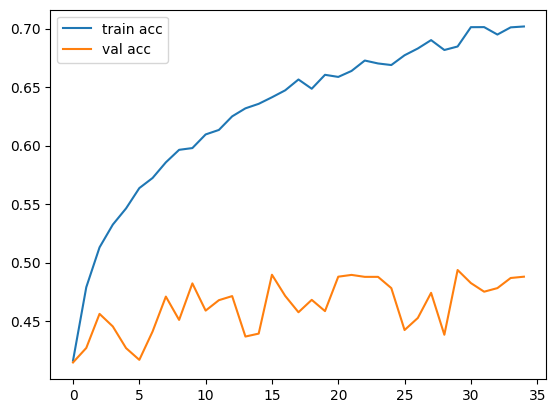

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend()
plt.show()

# plot the accuracy
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [14]:
# Print the final training and validation accuracy
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print("Final Accuracy:", final_train_accuracy)
print("Final Validation Accuracy:", final_val_accuracy)

Final Accuracy: 0.7018307447433472
Final Validation Accuracy: 0.48794087767601013


In [15]:
model.save('mobilnet.h5')

In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from keras.preprocessing.image import load_img

import numpy as np

# Assuming 'model' is already defined
model = load_model('mobilnet.h5')


# Dictionary mapping class indices to class labels
class_dict = {
     0:'angry',
    1:'disgust',
    2:'fear',
    3:'happy',
    4:'neutral',
    5:'sad',
    6:'surprise'
}

image_path = r'data\test\surprise\PrivateTest_914251.jpg'
image = load_img(image_path, target_size=(224, 224))
img = np.array(image)
img = preprocess_input(img)
img = img.reshape(1, 224, 224, 3)

prediction = model.predict(img)

# Get the predicted class index
predicted_class_index = np.argmax(prediction)

# Get the corresponding class label
predicted_class_label = class_dict[predicted_class_index]

# Print the predicted class label
print(f"The predicted class is: {predicted_class_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
The predicted class is: surprise


In [17]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from keras.preprocessing.image import load_img

import numpy as np

# Assuming 'model' is already defined
model = load_model('mobilnet.h5')


# Dictionary mapping class indices to class labels
class_dict = {
     0:'angry',
    1:'disgust',
    2:'fear',
    3:'happy',
    4:'neutral',
    5:'sad',
    6:'surprise'
}

image_path = r'data\test\surprise\PrivateTest_914251.jpg'
image = load_img(image_path, target_size=(224, 224))
img = np.array(image)
img = preprocess_input(img)
img = img.reshape(1, 224, 224, 3)

prediction = model.predict(img)

# Get the predicted class index
predicted_class_index = np.argmax(prediction)

# Get the corresponding class label
predicted_class_label = class_dict[predicted_class_index]

# Print the predicted class label
print(f"The predicted class is: {predicted_class_label}")                                    

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 997ms/step
The predicted class is: surprise
